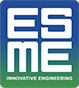 
<div class="alert alert-block alert-info" style="margin-top: 10px; padding: 10px; background: linear-gradient(to right, #f7f9fa, #d9edfb);">
    <h1 style="margin-left: 85px">APP 3 - Les tris</h1>
</div>

Importation de la librairie *pandas* pour lire le fichier .csv

In [115]:
import pandas as pd

resultats = "results.csv"
affichage = pd.read_csv(resultats)

print(affichage.head())
print(affichage.columns)




   Unnamed: 0 AgeGroup BikeTimeConverted          FullName Gender Country  \
0           0     MPRO           4:16:02       Jan Frodeno      M      DE   
1           1     MPRO           4:18:11  Timothy Odonnell      M      US   
2           2     MPRO           4:15:04  Sebastian Kienle      M      DE   
3           3     MPRO           4:24:01       Ben Hoffman      M      US   
4           4     MPRO           4:14:44      Cameron Wurf      M      AU   

  EventStatus  FinishRankGender  FinishRankGroup  FinishRankOverall  \
0      Finish                 1                1                  1   
1      Finish                 2                2                  2   
2      Finish                 3                3                  3   
3      Finish                 4                4                  4   
4      Finish                 5                5                  5   

  FinishTimeConverted RunTimeConverted SwimTimeConverted  \
0             7:51:13          2:42:43          00

Fonction qui trie par genre les athlètes

In [ ]:
def tri_genre(affichage):
    choix = input('Quel est le genre choisi pour ce tri ? m/f')
    masculin = []
    feminin = []
    for i in range(0, len(affichage)) : 
        if affichage.iloc[i]['Gender'] == 'M':
            masculin.append(affichage.iloc[i])
        else:
            feminin.append(affichage.iloc[i])
    if choix == 'm':
        return masculin
    elif choix == 'f':
        return feminin
    else : 
        print("Mauvaise valeur entrée pour le choix")
print(tri_genre(affichage))

On a essayé de trier par age les athlètes, mais plusieurs soucis nous comparons souvent des int avec des str.

In [33]:
def extrait_age(categorie):
    ages = []
    for i in categorie :
        ages.append(i[1:])
    return ages
print(extrait_age(affichage['AgeGroup']))
affichage["AgeMin"] = extrait_age(affichage['AgeGroup'])


['PRO', 'PRO', 'PRO', 'PRO', 'PRO', 'PRO', 'PRO', 'PRO', 'PRO', 'PRO', 'PRO', 'PRO', 'PRO', 'PRO', 'PRO', 'PRO', 'PRO', 'PRO', 'PRO', 'PRO', 'PRO', 'PRO', 'PRO', 'PRO', 'PRO', 'PRO', 'PRO', 'PRO', 'PRO', 'PRO', 'PRO', 'PRO', 'PRO', '35-39', 'PRO', '35-39', 'PRO', 'PRO', '30-34', '25-29', 'PRO', '45-49', '35-39', '30-34', 'PRO', '35-39', 'PRO', '35-39', '30-34', 'PRO', 'PRO', '30-34', '30-34', 'PRO', '35-39', '40-44', '25-29', '35-39', '30-34', '25-29', '30-34', 'PRO', 'PRO', '35-39', '25-29', '45-49', '40-44', '40-44', '30-34', '35-39', 'PRO', 'PRO', '25-29', '35-39', '35-39', '35-39', '30-34', '30-34', '40-44', '35-39', '40-44', 'PRO', '35-39', '35-39', '30-34', '45-49', '30-34', '30-34', '45-49', '18-24', 'PRO', 'PRO', 'PRO', '35-39', '35-39', '25-29', '30-34', '25-29', '40-44', 'PRO', '25-29', '30-34', '35-39', '30-34', '30-34', '30-34', '30-34', '30-34', '25-29', '25-29', '25-29', '25-29', '18-24', 'PRO', '18-24', '40-44', '30-34', '40-44', '25-29', '35-39', '30-34', 'PRO', '30-34'

In [117]:
def tri_age_(annees):
    triee = [affichage.iloc[0]]
    for i in range(1,len(annees)):
        for j in range(len(triee)+1):
            if extrait_age(triee[j]) > annees[i]:
                triee.insert(j,annees[i])
                break
            if j == len(triee)-1:
                triee.append(annees[i])
    return triee
print(affichage.iloc[0])
print(tri_age(affichage['AgeMin']))
    

Unnamed: 0                            0
AgeGroup                           MPRO
BikeTimeConverted               4:16:02
FullName                    Jan Frodeno
Gender                                M
Country                              DE
EventStatus                      Finish
FinishRankGender                      1
FinishRankGroup                       1
FinishRankOverall                     1
FinishTimeConverted             7:51:13
RunTimeConverted                2:42:43
SwimTimeConverted              00:47:31
Transition1TimeConverted       00:01:58
Transition2TimeConverted       00:02:59
Name: 0, dtype: object


KeyError: 'AgeMin'

Ici, on a voulu ranger les heures, les minutes et les secondes au chrono de vélo pour pouvoir trier plus facilement, mais une erreur que nous n'arrivons pas à résoudre s'affiche, ce qui nous empêche de continuer notre tri sur le chrono.

In [211]:
affichage.iloc[0]['BikeTimeConverted']
def ranger_temps():
    h = []
    m = []
    s = []
    splitted = []
    for i in range(len(affichage)+1):
        splitted = str(affichage.iloc[i]['BikeTimeConverted']).split(':')
        for j in splitted:
            j = int(j)
        h.append(splitted[0])
        m.append(splitted[1])
        s.append(splitted[2])
    return h,m,s
print(ranger_temps())

IndexError: single positional indexer is out-of-bounds

In [82]:
def tri_bike_insertion(chrono):
    for i in range(1, len(chrono)):
        key = chrono[i]
        j = i - 1
        while j >= 0 and chrono[j] > key:
            chrono[j + 1] = chrono[j]
            j = j - 1
        chrono[j + 1] = key
    return chrono

liste=[76,32,65,2,80,11,7]
print(tri_bike_insertion(liste))

[2, 7, 11, 32, 65, 76, 80]
